In [47]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('weatherAUS.csv') # type: ignore
print(df)


              Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     17.5     32.3       1.0          NaN   
...            ...      ...      ...      ...       ...          ...   
145455  2017-06-21    Uluru      2.8     23.4       0.0          NaN   
145456  2017-06-22    Uluru      3.6     25.3       0.0          NaN   
145457  2017-06-23    Uluru      5.4     26.9       0.0          NaN   
145458  2017-06-24    Uluru      7.8     27.0       0.0          NaN   
145459  2017-06-25    Uluru     14.9      NaN       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  \
0            NaN           W           44.0          W  ... 

In [48]:
df.head()
df.shape
df.info()
df.isna().sum()
df['RainTomorrow'].value_counts(dropna=False)

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

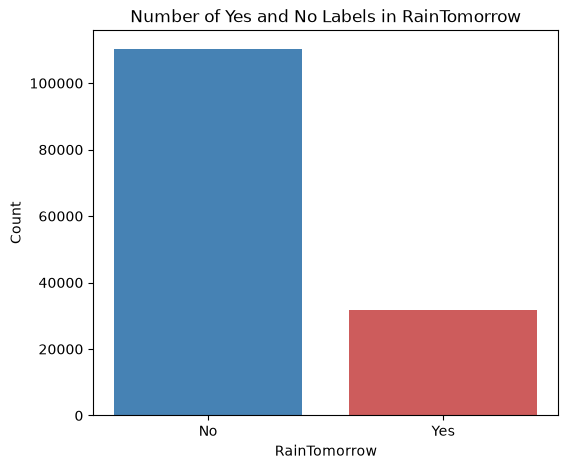

In [49]:
# Count the number of Yes and No labels in RainTomorrow
rain_counts = df['RainTomorrow'].value_counts()

# Create the bar chart
plt.figure(figsize=(6, 5))
plt.bar(rain_counts.index, rain_counts.values, color=['steelblue', 'indianred'])

plt.title('Number of Yes and No Labels in RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Count')

plt.show()

In [45]:
features_numerical = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
'Humidity9am', 'Humidity3pm', 'Pressure9am',
'Pressure3pm', 'Temp9am', 'Temp3pm']

# Create a complete-case DataFrame with the selected features and target
weather_subset = df[features_numerical + ['RainTomorrow']].dropna().copy()

# Convert the target labels to binary values
weather_subset['RainTomorrow'] = weather_subset['RainTomorrow'].map({'No': 0, 'Yes': 1})

print(f"Rows remaining after removing missing values: {len(weather_subset)}")
weather_subset.head()


Rows remaining after removing missing values: 119702


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainTomorrow
0,13.4,22.9,0.6,44.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0
1,7.4,25.1,0.0,44.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0
2,12.9,25.7,0.0,46.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0
3,9.2,28.0,0.0,24.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0
4,17.5,32.3,1.0,41.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0


In [46]:
# Create the temperature range from the existing complete-case data
weather_subset['TemperatureRange'] = (
    weather_subset['MaxTemp'] - weather_subset['MinTemp']
)

# Add the derived feature to the feature list
if 'TemperatureRange' not in features_numerical:
    features_numerical.append('TemperatureRange')

# Inspect the calculation
weather_subset[['MinTemp', 'MaxTemp', 'TemperatureRange']].head(10)

,MinTemp,MaxTemp,TemperatureRange
0,13.4,22.9,9.5
1,7.4,25.1,17.7
2,12.9,25.7,12.8
3,9.2,28.0,18.8
4,17.5,32.3,14.8
5,14.6,29.7,15.1
6,14.3,25.0,10.7
7,7.7,26.7,19.0
8,9.7,31.9,22.2
9,13.1,30.1,17.0


In [ ]:
from sklearn.model_selection import train_test_split

X = weather_subset[features_numerical]
y = weather_subset['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=2112,
    stratify=y
)

print(f"X_train size: {X_train.shape}")
print(f"X_test size: {X_test.shape}")
print(f"y_train size: {y_train.shape}")
print(f"y_test size: {y_test.shape}")

X_train size: (95761, 11)
X_test size: (23941, 11)
y_train size: (95761,)
y_test size: (23941,)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape: {X_test_scaled.shape}")

Scaled X_train shape: (95761, 11)
Scaled X_test shape: (23941, 11)


In [13]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=(10,),
max_iter = 300,
random_state = 2112)

# Train the neural network using the scaled training data
model.fit(X_train_scaled, y_train)

# Generate predictions for the test set
y_pred = model.predict(X_test_scaled)

print("Model training complete.")
print(f"Predictions generated: {len(y_pred)}")
print(y_pred[:10])

Model training complete.
Predictions generated: 23941
[0 0 0 0 0 0 0 0 0 0]


In [ ]:
import pandas as pd

results = pd.DataFrame({
'actual': y_test.to_numpy(),
'predicted': y_pred
})
results.head()


,actual,predicted
0,0,0
1,1,0
2,1,0
3,0,0
4,0,0


In [34]:
from unittest import result


actual = results['actual'].to_numpy()
predicted = results['predicted'].to_numpy()

TP = ((actual == 1) & (predicted == 1)).sum()
TN = ((actual == 0) & (predicted == 0)).sum()
FP = ((actual == 0) & (predicted == 1)).sum()
FN = ((actual == 1) & (predicted == 0)).sum()

print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f"Accuracy: {accuracy:.4f}")
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
print(f"Precision: {precision:.4f}")
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
print(f"Recall: {recall:.4f}")
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"F1 Score: {f1:.4f}")

from sklearn.metrics import (confusion_matrix, accuracy_score,
precision_score, recall_score, f1_score)


True Positives (TP): 2619
True Negatives (TN): 17808
False Positives (FP): 889
False Negatives (FN): 2625
Accuracy: 0.8532
Precision: 0.7466
Recall: 0.4994
F1 Score: 0.5985


In [37]:
import numpy as np
baseline_pred = np.zeros_like(y_test)

# Calculate baseline accuracy using the all-zero predictions
baseline_accuracy = (baseline_pred == y_test.to_numpy()).mean()

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"MLP accuracy: {accuracy:.4f}")
print(f"Improvement: {accuracy - baseline_accuracy:.4f}")


Baseline accuracy: 0.7810
MLP accuracy: 0.8532
Improvement: 0.0723


In [38]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Evaluate the original model
models = {
    "Original MLP": model,
    "Tuned MLP": MLPClassifier(
        hidden_layer_sizes=(20, 10),
        max_iter=300,
        random_state=2112
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=2112
    )
}

# Train the tuned MLP on scaled data
models["Tuned MLP"].fit(X_train_scaled, y_train)
tuned_pred = models["Tuned MLP"].predict(X_test_scaled)

# Train the tree-based model on the original feature values
models["HistGradientBoosting"].fit(X_train, y_train)
hgb_pred = models["HistGradientBoosting"].predict(X_test)

predictions = {
    "Original MLP": y_pred,
    "Tuned MLP": tuned_pred,
    "HistGradientBoosting": hgb_pred
}

comparison = []

for name, predictions_for_model in predictions.items():
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions_for_model),
        "Precision": precision_score(y_test, predictions_for_model, zero_division=0),
        "Recall": recall_score(y_test, predictions_for_model, zero_division=0),
        "F1 Score": f1_score(y_test, predictions_for_model, zero_division=0)
    })

comparison_df = pd.DataFrame(comparison).set_index("Model")
comparison_df.round(4)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Original MLP,0.8532,0.7466,0.4994,0.5985
Tuned MLP,0.8574,0.7359,0.5446,0.6260
HistGradientBoosting,0.8571,0.7542,0.5154,0.6124
